In [1]:
import os
import sys
from numpy import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import interpolate
# import dynamo as dyn
from scipy.integrate import odeint,ode,quad
from scipy import optimize
import astropy.constants as cons
#import plot_mesh
from matplotlib import ticker
from matplotlib.lines import Line2D
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.colors import LogNorm,Normalize, SymLogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

#ys.path.insert(0, '/home/yu/Programs/Athena/athena-df_20230314/vis/python')
sys.path.insert(0, '/home/izx/athena_sublimation/vis/python')
import athena_read
import re
from scipy.integrate import solve_ivp, odeint
import pickle
import random as rd
from scipy.stats import gaussian_kde, norm
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import ArrowStyle
from matplotlib.patches import FancyArrowPatch, Arrow
from copy import deepcopy

In [2]:
from preplot import pol2car, car2pol, dfdx_2pts, dfdx_5pts, dfdx_7pts, curl_in_polar_rlog,v_Intpl_Sph2car,scaler_Intpl_Sph2car
plt.rcParams.update({'font.size': 15})

In [3]:
AU = cons.au.cgs.value
YR = (365.2425*24*3600)
M_sun = cons.M_sun.cgs.value
M_e = cons.M_earth.cgs.value
M_j = cons.M_jup.cgs.value
GM_sun = cons.GM_sun.cgs.value
GM_e = cons.GM_earth.cgs.value
L_sun = cons.L_sun.cgs.value
R_sun = cons.R_sun.cgs.value
sigma_sb = cons.sigma_sb.cgs.value

In [4]:
# disk slope
T_slope = -0.5
Cs_slope = T_slope/2
H_slope = Cs_slope + 1.5
sigma_slope = -(Cs_slope + H_slope)

rho_slope = sigma_slope - H_slope
p_slope = T_slope + rho_slope

# disk parameter
M_star = 1.0 # Msun
# M_p = 2.4*M_j/M_e # M_e
a_semi = 3.0 # au, semi-major axis
a0 = 3.0 # r0, reference position of disk temperature/density profile
T_profile = lambda r: 150.0*(r/3.0)**(T_slope)
# H_profile = lambda r: 0.033*AU*(r/1.0)**(H_slope)
# default value
T0 = T_profile(a0) # Temperature at planet position
Mdot_gas = 1.e-8*M_sun/YR
alpha = 3.e-3

Cs0 = sqrt(cons.k_B.cgs.value*T0/(2.34*cons.m_p.cgs.value))
UNIT_T = (365.2425*24*3600)/(2*pi)*(a0)**(1.5)*M_star**(-0.5) # 1/omega at planet position
Sigma0 = Mdot_gas/(3.0*pi*alpha*Cs0**2*UNIT_T) # gas surface density at planet position
sigma_profile = lambda r: Sigma0*(r/a0)**(sigma_slope)

print("d_slope=",rho_slope) # midplane gas density slope
print("p_over_d_slope=",p_slope-rho_slope)
print("sigma0=",Sigma0)

d_slope= -2.25
p_over_d_slope= -0.5
sigma0= 161.3840152840912


In [5]:
# global dimensionless quantity
mu_He = 4
mu_H2 = 2
mu_xy = 2.34

UNIT_V = sqrt(cons.k_B.cgs.value*T0/(mu_xy*cons.m_p.cgs.value))
UNIT_L = UNIT_V*UNIT_T  # scale height at reference poistion
UNIT_DEN = Sigma0/(sqrt(2*pi)*UNIT_L)
UNIT_Fm = (UNIT_L**3*UNIT_DEN/UNIT_T)/(M_sun/YR)
UNIT_PRS = UNIT_DEN*UNIT_V**2
kB_mp_cgs = cons.k_B.cgs.value/cons.m_p.cgs.value
kB_mp = cons.k_B.cgs.value/cons.m_p.cgs.value/(UNIT_V**2)

print("UNIT_T=%.10e"%(UNIT_T))
print("UNIT_V=%.10e"%(UNIT_V))
print("UNIT_L=%.10e"%(UNIT_L))
print("UNIT_DEN=%.10e"%(UNIT_DEN))
print("UNIT_Fm=%.10e"%(UNIT_Fm))
print("UNIT_PRS=%.10e"%(UNIT_PRS))
print("KELVIN=%.10e"%(1/kB_mp))

UNIT_T=2.6097389234e+07
UNIT_V=7.2741198061e+04
UNIT_L=1.8983553591e+12
UNIT_DEN=3.3915097492e-11
UNIT_Fm=1.4109696874e-07
UNIT_PRS=1.7945434134e-01
KELVIN=6.4102564103e+01


In [6]:
class chem:
    name = ''

    def __init__(self,name,mu,T_a,P_eq,L_heat):
        self.name = name
        self.mu = mu
        self.T_a = T_a
        self.P_eq = P_eq
        self.R = kB_mp_cgs/mu
        self.L_heat = L_heat

In [7]:
# gas property
# water:
mu_water = 18
P_eq_water = 1.14e13
L_heat_water = 2.75e10
R_water = kB_mp_cgs/mu_water
T_a_water = 6062
chem_H2O = chem('H2O',18,T_a_water,P_eq_water,L_heat_water)

In [8]:
mu_z = chem_H2O.mu
P_eq0 = chem_H2O.P_eq / UNIT_PRS
L_heat = chem_H2O.L_heat / UNIT_V**2
T_a = chem_H2O.T_a
print("P_eq0=%.10e"%(P_eq0))
print("L_heat=",L_heat)
print("T_a=",T_a)

P_eq0=6.3525908123e+13
L_heat= 5.197228298162747
T_a= 6062


In [9]:
# dimensionless quantity used in intial set-up.
L_norm = (AU/UNIT_L)
r0 = a0*L_norm
# required resolution
rin = 1.0*L_norm
rout = 4.0*L_norm
Nrad = 300

GM = (r0)**3
tlim = 2e5*YR/UNIT_T
dt = 1e3*YR/UNIT_T

In [10]:
def face_f_2_cos(x2min,x2max,cell_width_ratio,num_face):
    x = linspace(0,1,num_face)
    w = arccos(1-x)/(pi/2)
    tmp = w*(x2max-x2min) + x2min
    
    return tmp


def face_f_2_power(x2min,x2max,cell_width_ratio,num_face):
    x = linspace(0,1,num_face)
    w = (x)**(1/3)
    tmp = w*(x2max-x2min) + x2min
    
    return tmp

def Get_kappa(kappa0, d2g, fv):
    return kappa0*(1.0-fv)*UNIT_DEN*UNIT_L


def formatnum(x,pos):
    return '$10^{%.0f}$' % (log10(x))

In [11]:
# Set global font properties
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'  # Replace with your chosen font
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({'font.size': 15})

In [12]:
from copy import deepcopy
half = False
for nstep in [4000]:
    dT = 1
    # read the data
    DIR = '/mnt/sdc/Zhixuan/athena_works/new_snowline/'
    # DIR = '/home/yu/Programs/Athena/work/output/snowline_2D/output4/'
    # DIR = '/mnt/disk1/dataYu/output/snowline_2D/output37/'
    #----------------------------------------
    # primitive data read
    #----------------------------------------
    filename = DIR+'iceline.out1.'+str(nstep).rjust(5,'0')+'.athdf'
    print("Reading file: ", filename)
    data_prim= athena_read.athdf(filename,face_func_2=face_f_2_power, num_ghost=0)
    rad = data_prim['x1v']/ L_norm
    theta = data_prim['x2v']
    phi = data_prim['x3v']
    
    phi_f = data_prim['x3f']
    phi_f[-1] = phi_f[0]
    phi[-1] = phi[0] = 0.0
    theta_f = data_prim['x2f']
    rad_f = data_prim['x1f']/ L_norm
    
    simu_time = data_prim['Time']
    
    ## (phi*theta*R)
    rho = data_prim['rho']
    prs = data_prim['press']
    vx1 = data_prim['vel1']
    vx2 = data_prim['vel2']
    vx3 = data_prim['vel3']
    
    dust_1_rho = data_prim['dust_1_rho']
    dust_1_vx1 = data_prim['dust_1_vel1']
    dust_1_vx2 = data_prim['dust_1_vel2']
    dust_1_vx3 = data_prim['dust_1_vel3']
    
    dust_2_rho = data_prim['dust_2_rho']
    
    dust_3_rho = data_prim['dust_3_rho']
    dust_3_vx1 = data_prim['dust_3_vel1']
    dust_3_vx2 = data_prim['dust_3_vel2']
    dust_3_vx3 = data_prim['dust_3_vel3']  


    #-----------------------------------------
    # user defined variable read
    # #---------------------------------------
    data_uov= athena_read.athdf(DIR+'iceline.out2.'+str(nstep).rjust(5,'0')+'.athdf',face_func_2=face_f_2_power, num_ghost=0)
    tem = data_uov['Tem']
    # dif = data_uov['dif']
    st = data_uov['st_1']

    tem_equi = data_uov['st_1']
    m_p = data_uov['m_p_1']

    s_p = data_uov['s_p_1']

    # dfvdt = data_uov['dfvdt']
    q_z = data_uov['q_z']
    q_latent = data_uov['q_latent']
    q_diff = data_uov['q_diff']
    flx_ice_x1 = data_uov['flx_ice_x1_1']
    flx_ice_x2 = data_uov['flx_ice_x2_1']
    flx_vap_x1 = data_uov['flx_vap_x1']
    flx_vap_x2 = data_uov['flx_vap_x2']
    flx_x1 = data_uov['flx_x1']
    flx_x2 = data_uov['flx_x2']
    # gamma = data_uov['gamma']
    
    # face coordinate
    index_phi = 0
    THETA, PHI, R = meshgrid(theta_f,phi_f,rad_f)
    x = R* sin(THETA) * cos(PHI)
    y = R* sin(THETA) * sin(PHI)
    z = R* cos(THETA)
    x_xz = x[index_phi,:,:].T
    y_xz = z[index_phi,:,:].T
    
    # cell center coordinate
    THETA, PHI, R = meshgrid(theta,phi,rad)
    x = R* sin(THETA) * cos(PHI)
    y = R* sin(THETA) * sin(PHI)
    z = R* cos(THETA)
    # x_xz_c = x[index_phi,:,:].T
    # y_xz_c = z[index_phi,:,:].T
    x_xz_c = x_xz[1:,1:]
    y_xz_c = y_xz[1:,1:]
    
    # cell area
    dR = data_prim['x1f'][1:]-data_prim['x1f'][0:-1]
    dtheta = data_prim['x2f'][1:]-data_prim['x2f'][0:-1]
    dphi = array([2.0*pi])
    dtheta_3D, dphi_3D, dR_3D = meshgrid(dtheta,dphi, dR)
    theta_3D, phi_3D, R_3D = meshgrid(data_prim['x2v'],array([pi]),data_prim['x1v'])
    
    dS_R = R_3D**2 *sin(theta_3D) * dtheta_3D* dphi_3D
    dS_theta = R_3D*sin(theta_3D) * dR_3D* dphi_3D
    dS_phi = R_3D*dR_3D*dtheta_3D
    
    # unit of flux
    flx_ice_x1 *= dS_R* UNIT_Fm 
    flx_vap_x1 *= dS_R* UNIT_Fm
    flx_ice_x2 *= dS_theta* UNIT_Fm
    flx_vap_x2 *= dS_theta* UNIT_Fm
    flx_x1 *= dS_R* UNIT_Fm
    flx_x2 *= dS_theta* UNIT_Fm
    
    # slices
    index_phi = 0
    rho_xz = rho[index_phi,:,:].T
    dust_1_rho_xz = dust_1_rho[index_phi,:,:].T
    dust_2_rho_xz = dust_2_rho[index_phi,:,:].T
    dust_3_rho_xz = dust_3_rho[index_phi,:,:].T

    # prs_xz = prs[index_phi,:,:].T
    tem_xz = tem[index_phi,:,:].T
    tem_equi_xz = tem_equi[index_phi,:,:].T
    st_xz = st[index_phi,:,:].T
    # dif_xz = dif[index_phi,:,:].T
    # dfvdt_xz = dfvdt[index_phi,:,:].T
    q_z_xz = q_z[index_phi,:,:].T
    q_latent_xz = q_latent[index_phi,:,:].T
    q_diff_xz = q_diff[index_phi,:,:].T
    m_p_xz = m_p[index_phi,:,:].T
    s_p_xz = s_p[index_phi,:,:].T

Reading file:  /mnt/sdc/Zhixuan/athena_works/new_snowline/iceline.out1.04000.athdf


In [13]:
flx_vap_x1


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [14]:
#plot the rho
plt.figure(figsize=(12,6)) 
d2g_snow = 1.e-3

dust_1_rho_mod = deepcopy(dust_1_rho_xz)
dust_3_rho_mod = deepcopy(dust_3_rho_xz)

dust_1_rho_mod[dust_1_rho_xz/rho_xz < d2g_snow] = nan
dust_3_rho_mod[dust_3_rho_xz/rho_xz < d2g_snow] = nan


plt.contourf(x_xz_c,y_xz_c,dust_3_rho_mod,levels = logspace(log10(d2g_snow),log10(2.0),15), norm = LogNorm(), cmap = 'Greens', alpha = 0.5, extend = 'both')
plt.colorbar(label='small particle density (g/cm$^3$)')
plt.contourf(x_xz_c,y_xz_c,dust_1_rho_mod,levels = logspace(log10(d2g_snow),log10(2.0),15), norm = LogNorm(), cmap = 'Blues', alpha = 1, extend = 'both')

plt.colorbar(label='large particle density (g/cm$^3$)')
ice_rho_xz_tot = dust_1_rho_xz + dust_3_rho_xz
plt.contour(x_xz_c,y_xz_c,ice_rho_xz_tot/rho_xz,levels = [d2g_snow], cmap = 'Greens_r', alpha = 0.7, linewidths = 5.0)

plt.savefig('./rho_contour.png',dpi = 300, bbox_inches='tight')
plt.close()


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

/tmp/ipykernel_3222077/3934598986.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  if(fabs(x1_exp_half[i]/x3_exp[j]) < tan(0.8) or (x1_exp_half[i]**2 + x3_exp[j]**2 > xs**2) ):
/tmp/ipykernel_3222077/3934598986.py:93: RuntimeWarning: divide by zero encountered in divide
  P_eq = P_eq0*exp(-T_a/tem_xz)
/tmp/ipykernel_3222077/3934598986.py:95: RuntimeWarning: invalid value encountered in divide
  rate_ratio = P_eq/P_vap * (dust_3_rho_xz/dust_1_rho_xz)


Text(0.5, 63.7222222222222, '$r$ [au]')

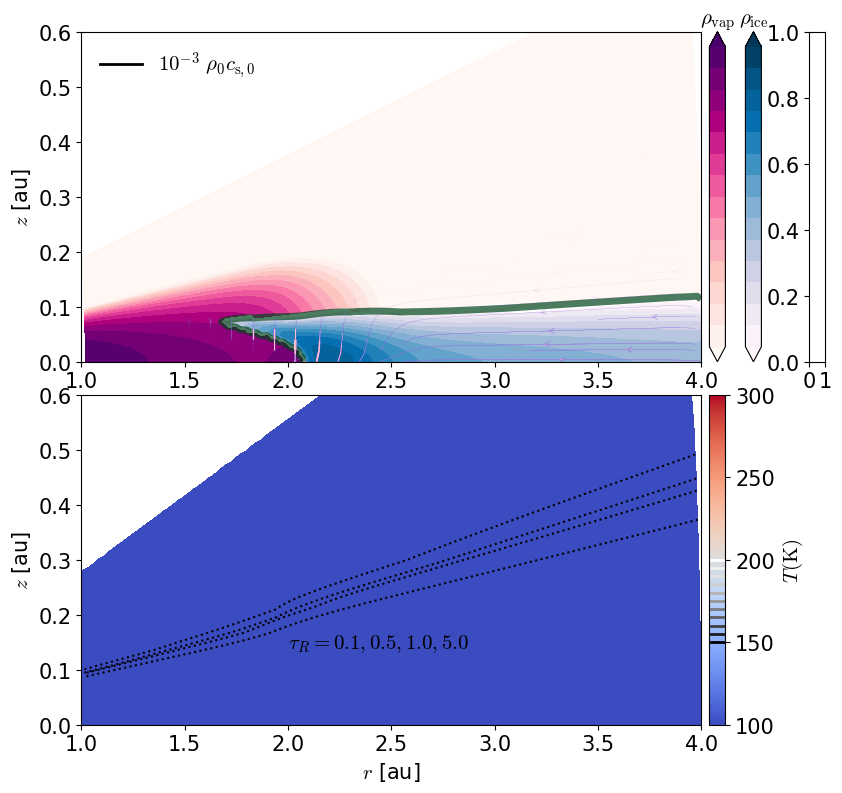

In [15]:
#import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'  # Switch to sans-serif
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # Fallback fonts

R_inner = 1.0
xs = 4.0
zs = 0.6
numx = 64
numy = 16
numz = 32
x1_exp_half = linspace(R_inner,xs,numx)
# x2_exp_half = linspace(R_inner,ys,numy)
x3_exp = linspace(0.0,zs,numz)
slice_exp = array([0.0])

# xz
vx,vy,vz = v_Intpl_Sph2car(rad,theta,phi,x1_exp_half,slice_exp,x3_exp,vx1.T,vx2.T,vx3.T) 
vx_xz = vx[:,0,:]
vy_xz = vy[:,0,:]
vz_xz = vz[:,0,:]

dust_1_vx,dust_1_vy,dust_1_vz = v_Intpl_Sph2car(rad,theta,phi,x1_exp_half,slice_exp,x3_exp,dust_1_vx1.T,dust_1_vx2.T,dust_1_vx3.T) 
dust_1_vx_xz = dust_1_vx[:,0,:]
dust_1_vy_xz = dust_1_vy[:,0,:]
dust_1_vz_xz = dust_1_vz[:,0,:]

water_flx_x, water_flx_y, water_flx_z = v_Intpl_Sph2car(rad,theta,phi,x1_exp_half,slice_exp,x3_exp,(flx_vap_x1 + flx_ice_x1).T,(flx_vap_x2 + flx_ice_x2).T, (flx_vap_x1 + flx_ice_x1).T * 0.0)
water_flx_x_xz = water_flx_x[:,0,:]
water_flx_z_xz = water_flx_z[:,0,:]

ice_flx_x, ice_flx_y, ice_flx_z = v_Intpl_Sph2car(rad,theta,phi,x1_exp_half,slice_exp,x3_exp,(flx_ice_x1).T,(flx_ice_x2).T, (flx_ice_x1).T * 0.0)
ice_flx_x_xz = ice_flx_x[:,0,:]
ice_flx_z_xz = ice_flx_z[:,0,:]

for j in range(numz):
    for i in range(numx):
        if(fabs(x1_exp_half[i]/x3_exp[j]) < tan(0.8) or (x1_exp_half[i]**2 + x3_exp[j]**2 > xs**2) ):
            vx_xz[j,i] = 0.0
            vz_xz[j,i] = 0.0
            dust_1_vx_xz[j,i] = 0.0
            dust_1_vz_xz[j,i] = 0.0
            water_flx_x_xz[j,i] = 0.0
            water_flx_z_xz[j,i] = 0.0
            ice_flx_x_xz[j,i] = 0.0
            ice_flx_z_xz[j,i] = 0.0
                
# # 3D
# vx,vy,vz = v_Intpl_Sph2car(rad,theta,phi,x1_exp,x2_exp,x3_exp,vx1.T,vx2.T,vx3.T)
normal = sort(sqrt(vx_xz**2 + vz_xz**2),axis = None)[-10]# velocity normalization
normal2 = sort(sqrt(water_flx_x_xz**2 + water_flx_z_xz**2),axis = None)[-2]
# normal2 = sort(sqrt(ice_flx_x_xz**2 + ice_flx_z_xz**2),axis = None)[-2]

# calc optical depth
tau_opt = zeros(rho_xz.shape)
for j in range(tau_opt.shape[1]):
    dx2 = rad*L_norm*(theta_f[1]-theta_f[0])
    tau_opt[:,j] += tau_opt[:,j-1] + rho_xz[:,j]*Get_kappa(1.0, 0.0, dust_3_rho_xz/rho_xz)[:,j] * dx2

# define r_snow based on d2g
d2g_snow = 1.e-3
dust_3_rho_mod = deepcopy(dust_3_rho_xz)
dust_1_rho_mod = deepcopy(dust_1_rho_xz)
dust_3_rho_mod[dust_1_rho_xz/rho_xz > d2g_snow] = nan
dust_1_rho_mod[dust_1_rho_xz/rho_xz < d2g_snow] = nan

fig,axes = plt.subplots(nrows = 2, ncols = 1,figsize = (8,9))
fig.set_facecolor('white')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace= 0.1)
ax = axes.flatten()

# the vapor
ax0 = ax[0].contourf(x_xz_c,y_xz_c,dust_3_rho_mod,levels = logspace(log10(d2g_snow),log10(2.0),15), norm = LogNorm(), cmap = 'RdPu', alpha = 1, extend = 'both')
# the ices
ax00 = ax[0].contourf(x_xz_c,y_xz_c,dust_1_rho_mod,levels = logspace(log10(d2g_snow),log10(2.0),15), norm = LogNorm(), cmap = 'PuBu', alpha = 1, extend = 'both')

# ax0 = ax[0].pcolormesh(x_xz,y_xz,q_diff_xz,norm = Normalize(vmin = -0.01,vmax = 0.01,clip = True) ,cmap = 'coolwarm', alpha = 1)
# ax0 = ax[0].pcolormesh(x_xz,y_xz,st_xz * (x_xz_c/3.0)**(-1.5),norm = Normalize(vmin = 0.01,vmax = 0.3,clip = True) ,cmap = 'coolwarm', alpha = 1)

#zxl: this we change to the sum of the ice in different populations.
ice_rho_xz_tot = dust_1_rho_xz
ax[0].contour(x_xz_c,y_xz_c,ice_rho_xz_tot/rho_xz,levels = [d2g_snow], cmap = 'Greens_r', alpha = 0.7, linewidths = 5.0)
# ax[0].contour(x_xz_c,y_xz_c,r_snow_2d(tem_xz,rho_xz,0.4) ,levels = [1.e-3,1.0,1.e3], cmap = 'Greens_r', alpha = 0.7, linewidths = 5.0)

# normalized lw of flux
lw_flx = sqrt(water_flx_x_xz**2 + water_flx_z_xz**2)/normal2
lw_flx2 = sqrt(ice_flx_x_xz**2 + ice_flx_z_xz**2)/normal2
lw_flx3 = sqrt(water_flx_x_xz**2 + water_flx_z_xz**2)/normal2
lw_flx = 2.0*sqrt(lw_flx)
lw_flx2 = 2.0*sqrt(lw_flx2)
lw_flx3 = 2.0*sqrt(lw_flx3)

# sublimation / condensation rate
P_eq = P_eq0*exp(-T_a/tem_xz)
P_vap = dust_3_rho_xz * kB_mp * tem_xz / mu_z
rate_ratio = P_eq/P_vap * (dust_3_rho_xz/dust_1_rho_xz)

# legend
legends = [Line2D([0], [0], color='k', lw=2, label=r'$10^{-3}~\rho_{0}c_{\mathrm{s,0}}$')]
ax[0].legend(handles=legends, loc='upper left',fontsize = 15,frameon = False)

ax[0].streamplot(x1_exp_half,x3_exp, ice_flx_x_xz/normal2, ice_flx_z_xz/normal2,linewidth = lw_flx2, arrowstyle = '->', density = 1.0, broken_streamlines = True, color ='blue')
ax[0].streamplot(x1_exp_half,x3_exp, water_flx_x_xz/normal2, water_flx_z_xz/normal2,linewidth = lw_flx3, arrowstyle = '->', density = 1.0, broken_streamlines = True, color ='pink')
# ax[0].streamplot(x1_exp_half,x3_exp, water_flx_x_xz/normal2, water_flx_z_xz/normal2,linewidth = lw_flx, arrowstyle = '->', density = 1.5, broken_streamlines = True, color ='w')
# ax[0].streamplot(x1_exp_half,x3_exp, (gas_flx_x_xz- vap_flx_x_xz)/normal2, (gas_flx_z_xz-vap_flx_z_xz)/normal2,linewidth = lw_flx4, arrowstyle = '->', density = 1.6, broken_streamlines = True, color ='white')
# ax[0].streamplot(x1_exp_half,x3_exp, vx_xz/normal, vz_xz/normal,linewidth = 0.75
#                 ,arrowstyle = '->', density = 2.0, broken_streamlines = True, color ='grey', norm = LogNorm(1.e-5,1.e-2,clip = True))

# temperature
ax1 = ax[1].pcolormesh(x_xz,y_xz,tem_xz,norm = Normalize(vmin = 100,vmax = 300,clip = True) ,cmap = 'coolwarm', alpha = 1)
C_Tem = ax[1].contour(x_xz_c,y_xz_c,tem_xz,levels = linspace(150,200,11,endpoint=True), cmap = 'Greys_r', alpha = 1.0, linewidths = 1.0)
C = ax[1].contour(x_xz_c,y_xz_c,tau_opt,levels = array([0.1,0.5,1.0,5.0]), colors = 'black', linestyles = 'dotted')
ax[1].annotate(r'$\tau_{R} = 0.1, 0.5, 1.0, 5.0$',xy = (2.0,0.14),xytext = (2.0,0.14),fontsize = 15)

#===
divider = make_axes_locatable(ax[0])
cax = fig.add_axes([ax[0].get_position().x1+0.01,ax[0].get_position().y0,0.02,ax[0].get_position().height])
cl0 = fig.colorbar(ax0,cax = cax)
# cl0.set_ticks([0.01,0.03,0.05])
# cl0.ax.set_title('St',fontsize=12)
cl0.set_ticks([])
cl0.ax.set_title(r'$\rho_{\mathrm{vap}}$',fontsize = 15)
#===
cax1 = fig.add_axes([ax[0].get_position().x1+0.055,ax[0].get_position().y0,0.02,ax[0].get_position().height])
cl00 = fig.colorbar(ax00, cax = cax1,format = ticker.FuncFormatter(formatnum))
cl00.set_ticks([])
cl00.ax.set_title(r'$\rho_{\mathrm{ice}}$',fontsize = 15)


cax11 = fig.add_axes([ax[0].get_position().x1+0.135,ax[0].get_position().y0,0.02,ax[0].get_position().height])


divider = make_axes_locatable(ax[1])
cax = fig.add_axes([ax[1].get_position().x1+0.01,ax[1].get_position().y0,0.02,ax[1].get_position().height])
cl1 = fig.colorbar(ax1,cax = cax)
cl1.set_label(r'$T(\mathrm{K})$')
cb_ymin, cb_ymax = cl1.ax.get_ylim()
# Get colors from the contourf object
# colors = C_Tem.get_array()
plt.draw() # Force the figure to update and draw to get the colors
colors = C_Tem.get_edgecolors()  # Get the edge colors of the contour lines
# colors = C_Tem.colors
# Define levels for the second contour (make sure these are within the range of Z1)
second_contour_levels = C_Tem.levels
# Add lines to the colorbar
color_id = 0
for level in second_contour_levels:
    # Normalize level value to colorbar scale
    fmax = ax1.get_clim()[1]
    fmin = ax1.get_clim()[0]
    norm_level = (level - fmin) / (fmax - fmin)
    # Calculate y position on the colorbar
    y = cb_ymin + norm_level * (cb_ymax - cb_ymin)
    # Choose the color
    color = colors[color_id]
    color_id += 1
    # Draw a horizontal line on the colorbar
    cl1.ax.hlines(y, 0, 1, color=color, linewidth=2)

for i in range(len(list(ax))):
    ax[i].set_xlim(R_inner,xs)
    ax[i].set_ylim(0,zs)
    # ax[i].set_aspect(1)

ax[0].set_ylabel('$z$ [au]',fontsize =15)
ax[1].set_ylabel('$z$ [au]',fontsize =15)
ax[1].set_xlabel('$r$ [au]',fontsize =15)

In [16]:
xx_exp = linspace(rin/L_norm,4.0,320)
zz_exp = linspace(-1.0,1.0,160)[80:]
xx_exp_mesh, zz_exp_mesh = meshgrid(xx_exp,zz_exp)

dif = (x/3.0)*0.003
dif_intpl = (xx_exp_mesh/3.0)*0.003

rho_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,rho.T)[:,0,:]
dust_1_rho_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,dust_1_rho.T)[:,0,:]
dust_2_rho_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,dust_2_rho.T)[:,0,:]
dust_3_rho_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,dust_3_rho.T)[:,0,:]


dif_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,dif.T)[:,0,:]
st_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,st.T)[:,0,:]
st_intpl *= (xx_exp_mesh/3)**(-1.5)
dif_peb_intpl = dif_intpl/(1.0 + st_intpl**2)
Tem_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,tem.T)[:,0,:]
prs_intpl = scaler_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,prs.T)[:,0,:]
vx,vy,vz = v_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,vx1.T,vx2.T,vx3.T)
vx_intpl = vx[:,0,:]
vy_intpl = vy[:,0,:]
vz_intpl = vz[:,0,:]

dust_1_vx,dust_1_vy,dust_1_vz = v_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,dust_1_vx1.T,dust_1_vx2.T,dust_1_vx3.T)
dust_1_vx_intpl = dust_1_vx[:,0,:]
dust_1_vy_intpl = dust_1_vy[:,0,:]
dust_1_vz_intpl = dust_1_vz[:,0,:]

# flux measured from simulation
flux_ice_x,flux_ice_z,flux_ice_z = v_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,(flx_ice_x1/dS_R).T, (flx_ice_x2/dS_theta).T, 0.0*flx_ice_x2.T)
flux_ice_x_intpl = flux_ice_x[:,0,:]
flux_ice_z_intpl = flux_ice_z[:,0,:]

flux_vap_x,flux_vap_z,flux_vap_z = v_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,(flx_vap_x1/dS_R).T, (flx_vap_x2/dS_theta).T, 0.0*flx_vap_x2.T)
flux_vap_x_intpl = flux_vap_x[:,0,:]
flux_vap_z_intpl = flux_vap_z[:,0,:]

flux_gas_x,flux_gas_z,flux_gas_z = v_Intpl_Sph2car(rad,theta,phi,xx_exp,array([0.0]),zz_exp,(flx_x1/dS_R).T, (flx_x2/dS_theta).T, 0.0*flx_x2.T)
flux_gas_x_intpl = flux_gas_x[:,0,:]
flux_gas_z_intpl = flux_gas_z[:,0,:]

for j in range(len(zz_exp)):
    for i in range(len(xx_exp)):
        if((fabs(zz_exp[j]/xx_exp[i]) > tan(pi/2-1.3) or (xx_exp[i]**2 + zz_exp[j]**2 > 4.0**2) or (xx_exp[i]**2 + zz_exp[j]**2 < 1.0**2))):
            rho_intpl[j,i] = 0.0
            dust_1_rho_intpl[j,i]= 0.0
            dust_2_rho_intpl[j,i]= 0.0
            dust_3_rho_intpl[j,i]= 0.0
            flux_vap_x_intpl[j,i] = 0.0
            flux_vap_z_intpl[j,i] = 0.0
            flux_gas_x_intpl[j,i] = 0.0
            flux_gas_z_intpl[j,i] = 0.0

In [17]:
# surface density
UNIT_SIGMA = UNIT_DEN*UNIT_L
dz = (zz_exp[1]-zz_exp[0])*AU/UNIT_L
dx = (xx_exp[1]-xx_exp[0])*AU/UNIT_L
sigma_gas = sum(rho_intpl*dz,axis = 0)*2.0 *UNIT_SIGMA # remember to add up 2 wings
sigma_ice1 = sum(dust_1_rho_intpl*dz,axis = 0)*2.0 *UNIT_SIGMA
sigma_sil1 = sum(dust_2_rho_intpl*dz,axis = 0)*2.0 *UNIT_SIGMA

sigma_ice = sigma_ice1
sigma_sil = sigma_sil1
sigma_vap = sum(dust_3_rho_intpl*dz,axis = 0)*2.0 *UNIT_SIGMA

In [18]:
dust_2_dif_x = zeros((len(zz_exp), len(xx_exp)))
for j in range(len(zz_exp)):
    dust_2_dif_x[j,:] = -rho_intpl[j,:]* dif_peb_intpl[j,:]*dfdx_5pts(xx_exp*L_norm, dust_2_rho_intpl[j,:]/rho_intpl[j,:])
for j in range(len(zz_exp)):
    for i in range(len(xx_exp)):
        if(isnan(dust_2_dif_x[j,i])):
            dust_2_dif_x[j,i] = 0.0
            
flux_sil = sum(dust_2_rho_intpl*dz*dust_1_vx_intpl + dust_2_dif_x*dz,axis = 0)*2.0 *(2*pi*xx_exp*L_norm)
UNIT_Fm = (UNIT_L**3*UNIT_DEN/UNIT_T)/(M_sun/YR)
flux_sil *= UNIT_Fm

/tmp/ipykernel_3222077/164872080.py:3: RuntimeWarning: invalid value encountered in divide
  dust_2_dif_x[j,:] = -rho_intpl[j,:]* dif_peb_intpl[j,:]*dfdx_5pts(xx_exp*L_norm, dust_2_rho_intpl[j,:]/rho_intpl[j,:])


In [19]:
flx_ice_x1[0].sum(axis=0)


array([-1.07823680e-14, -8.13413364e-15, -9.92057585e-15, -1.71820256e-14,
       -3.87689990e-14, -7.42112875e-14, -8.72785240e-14, -7.74299061e-14,
       -6.19492947e-14, -4.65530180e-14, -3.53024327e-14, -2.38260180e-14,
        8.62629538e-15,  7.03012979e-14,  5.03139519e-15, -1.12047442e-15,
       -1.79976367e-15, -3.97255819e-16, -8.31093540e-15, -2.45909622e-14,
       -2.33493874e-14, -2.58211519e-14, -2.40413801e-14, -4.28727507e-14,
       -1.73652138e-13, -3.04424226e-13, -3.20690851e-13, -1.68657743e-13,
       -9.17334628e-13, -1.62261292e-12, -2.16330389e-12, -1.62614501e-12,
       -4.71785074e-12, -8.30616752e-12, -1.28574788e-11, -1.14055207e-11,
       -2.56207783e-11, -4.21287572e-11, -4.08287004e-11, -6.81309661e-11,
       -1.11925275e-10, -1.49644422e-10, -1.73291122e-10, -2.99978162e-10,
       -4.22490243e-10, -4.23981018e-10, -6.59275643e-10, -7.90231616e-10,
       -1.03447227e-09, -1.43662974e-09, -1.39846160e-09, -1.88049895e-09,
       -2.27775163e-09, -

In [20]:
# simulation face flux
flux_gas_face = sum((flux_gas_x_intpl-flux_vap_x_intpl)*dz,axis = 0) *2.0 *(2*pi*xx_exp*L_norm)  # remember to add up 2 wings
flux_ice_face = sum(flux_ice_x_intpl*dz,axis = 0) *2.0 *(2*pi*xx_exp*L_norm)
flux_vap_face = sum(flux_vap_x_intpl*dz,axis = 0) *2.0 *(2*pi*xx_exp*L_norm)
flux_water_face = sum((flux_vap_x_intpl + flux_ice_x_intpl)*dz,axis = 0) *2.0 *(2*pi*xx_exp*L_norm)

## advective flux
flux_vap_adv = sum(dust_3_rho_intpl*dz*vx_intpl,axis = 0)*2.0 *(2*pi*xx_exp*L_norm)
flux_vap_adv *= UNIT_Fm

In [21]:
flux_vap_face

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

/tmp/ipykernel_3222077/1912962799.py:18: RuntimeWarning: invalid value encountered in divide
  r_out_index = len(xx_exp) - ((sigma_ice / sigma_sil)[::-1] > 1.5).argmax()


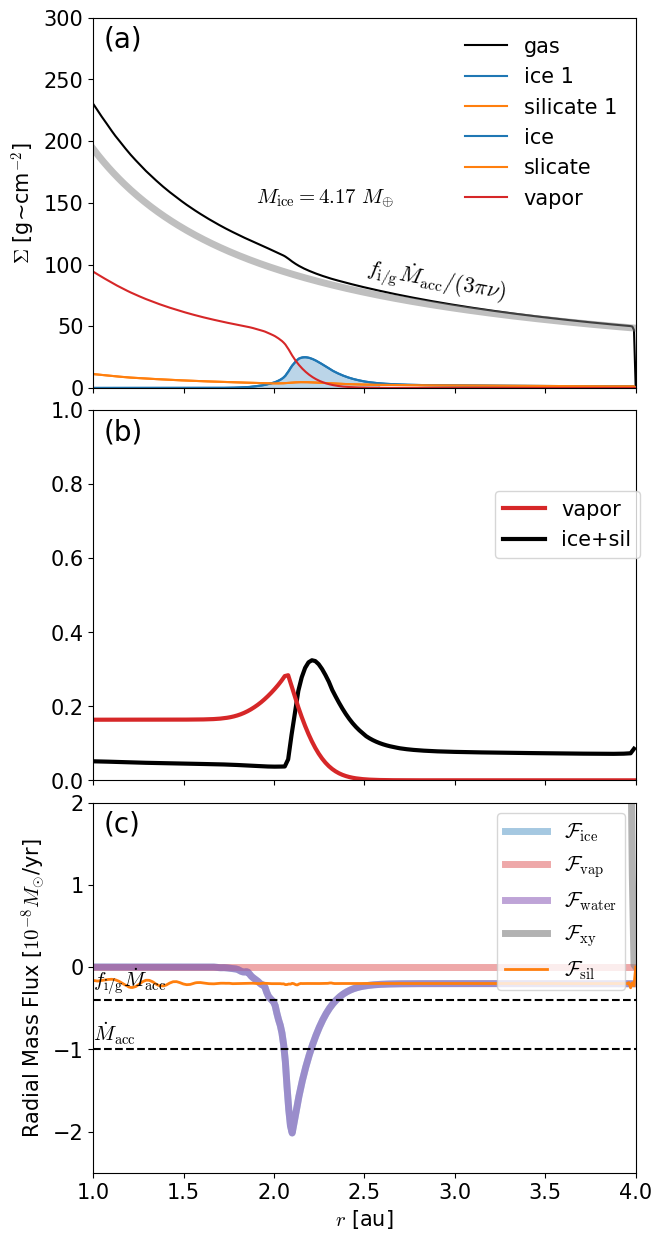

In [22]:
fig = plt.figure(figsize = (7,15),facecolor='white')
axes = fig.subplots(3,1)
ax = axes.flatten()
fig.subplots_adjust(hspace = 0.06)

# ax[0].plot(xx_exp,(sigma_gas-sigma_vap)*0.4, color = 'k', alpha = 1.0, label = '$ f_{\mathrm{i/g}} \Sigma_{\mathrm{xy}}$')
ax[0].plot(xx_exp,(sigma_gas)*0.4, color = 'k', linestyle='-', alpha = 1.0, label = 'gas')
ax[0].plot(xx_exp,sqrt(2*pi)*0.4*(xx_exp/3)**(-1)*UNIT_SIGMA,color = 'grey',linewidth = 5, alpha = 0.5)
ax[0].plot(xx_exp, sigma_ice1,'tab:blue', linestyle = '-', label = 'ice 1')
ax[0].plot(xx_exp, sigma_sil1,'tab:orange', linestyle = '-', label = 'silicate 1')


ax[0].plot(xx_exp,sigma_ice,'tab:blue', label = 'ice')
ax[0].plot(xx_exp,sigma_sil,'tab:orange', label = 'slicate')
ax[0].plot(xx_exp,sigma_vap,'tab:red', label = 'vapor')
# ice mass
r_in_index = sum(xx_exp < 1.0)
r_out_index = len(xx_exp) - ((sigma_ice / sigma_sil)[::-1] > 1.5).argmax()
dust_mass = sum(((sigma_ice)*2*pi* xx_exp* (xx_exp[1]-xx_exp[0]) * AU**2)[r_in_index:r_out_index])
ax[0].fill_between(xx_exp[r_in_index:r_out_index],0,sigma_ice[r_in_index:r_out_index],color = 'tab:blue',alpha = 0.3)
ax[0].annotate(r'$M_{\mathrm{ice}} = %.2f~M_{\oplus}$'%(dust_mass/M_e),xy = (0.3,0.5), xycoords = 'axes fraction',fontsize = 15)
ax[0].annotate(r'$f_{\mathrm{i/g}} \dot{M}_{\mathrm{acc}} /(3 \pi \nu)$',xy = (2.5,72), rotation = -10, fontsize = 16)
ax[0].set_ylim(0,300)
# ax[0].set_xlabel('$r$ [au]')
ax[0].set_ylabel(r'$\Sigma$ [g~cm$^{-2}$]')
ax[0].legend(loc = 'upper right',fontsize = 15,frameon = False)
# d2g
# ax00 = ax[0].twinx()
ax00 = ax[1]
ax00.plot(rad, ((dust_1_rho_xz + dust_2_rho_xz)/rho_xz)[:,-1], 'k', lw = 3.0,label = '$d/g$')
ax00.plot(rad, (dust_3_rho_xz/rho_xz)[:,-1],'tab:red', linestyle = '-', lw = 3.0)
ax00.set_ylim(0,1.0)


# # ax00.vlines(r_snow, -0.01, 1.2, linestyle = '--', color = 'grey')
# ax00.vlines(r_pk, -0.01, 1.2, linestyle = '--', color = 'grey')
# ax00.plot([2.177,2.617],[d2g_pk/2]*2,linestyle = '--', color = 'grey')
# # ax00.vlines(r_vap_outer, -0.01, 1.2, linestyle = '--', color = 'grey')
# ax00.annotate('$r_{\mathrm{snow,mid}}$',xy = (r_snow,0.8),fontsize = 20)
# ax00.annotate('$r_{\mathrm{pk}}$',xy = (r_pk,0.9),fontsize = 20)
# ax00.annotate('FWHM',xy = (r_pk - 0.1,0.27),fontsize = 15)
# # ax00.annotate('$r_{\mathrm{vap,outer}}$',xy = (r_vap_outer,0.9),fontsize = 20)
# ax00.set_ylabel('solid/vapor-to-gas ratio')

custom_lines2 = [Line2D([0], [10], color='tab:red', lw=3, linestyle='-',label='vapor'),
                Line2D([0,0.1], [0,0.1], color='k', lw=3, linestyle='-',label='ice+sil')]
ax[1].legend(handles=custom_lines2,handlelength = 2, loc = (0.74,0.6))

# flux

ax[2].plot(xx_exp,flux_ice_face*1e8,lw =5,color='tab:blue', alpha = 0.4, label = r'$\mathcal{F}_{\mathrm{ice}}$')
# ax[2].plot(xx_exp,flux_vap_face*1e8,lw =5,color='tab:red', alpha = 0.4, label = r'$\mathcal{F}_{\mathrm{vap}}$')
ax[2].plot(rad,flx_vap_x1[0].sum(axis=0)*1e8,lw =5,color='tab:red', alpha = 0.4, label = r'$\mathcal{F}_{\mathrm{vap}}$')
ax[2].plot(xx_exp,flux_water_face*1e8,lw =5,color='tab:purple', alpha = 0.6, label = r'$\mathcal{F}_{\mathrm{water}}$')
ax[2].plot(xx_exp,flux_gas_face*1e8,lw =5,color='grey', alpha = 0.6, label = r'$\mathcal{F}_{\mathrm{xy}}$')
ax[2].plot(xx_exp,flux_sil*1e8,'tab:orange', lw =2.0 , alpha = 1.0, linestyle = '-', label = r'$\mathcal{F}_{\mathrm{sil}}$')

ax[2].plot(xx_exp, -xx_exp/xx_exp,'k--')
ax[2].plot(xx_exp, -xx_exp/xx_exp*0.4,'k--')

ax[2].set_xlim(1.0,4.0)
ax[2].set_ylim(-2.5,2.0)
ax[2].annotate(r'$\dot{M}_{\mathrm{acc}}$',xy=(1.0,-0.9),fontsize = 15)
ax[2].annotate(r'$f_{\mathrm{i/g}} \dot{M}_{\mathrm{acc}}$',xy=(1.0,-0.25),fontsize = 15)
ax[2].set_ylabel(r'Radial Mass Flux [$10^{-8}M_{\odot}$/yr]',fontsize = 15)

ax[2].legend(loc='upper right')

for i in range(len(axes)):
    ax[i].set_xlim(1.,4.0)
for i in range(2):  
    ax[i].set_xticklabels([])   

ax[2].set_xlabel(r'$r$ [au]')

ax[0].annotate('(a)',xy = (0.02,0.92),xycoords = 'axes fraction',fontsize = 20)

ax[1].annotate('(b)',xy = (0.02,0.92),xycoords = 'axes fraction',fontsize = 20)
ax[2].annotate('(c)',xy = (0.02,0.92),xycoords = 'axes fraction',fontsize = 20)

plt.savefig('fig_snow_2d.png', bbox_inches='tight', dpi = 500)

In [23]:
flux_gas_face

array([2.98855065e-08, 3.04569690e-08, 3.10339394e-08, 3.30321074e-08,
       3.36496460e-08, 3.42718135e-08, 3.48983520e-08, 3.70504709e-08,
       3.77185300e-08, 3.83937358e-08, 3.90773740e-08, 3.97686037e-08,
       4.21251186e-08, 4.28622245e-08, 4.36088832e-08, 4.43631887e-08,
       4.51222567e-08, 4.76867225e-08, 4.84838738e-08, 4.92856863e-08,
       5.00881483e-08, 5.08931536e-08, 5.36486018e-08, 5.44919284e-08,
       5.53425425e-08, 5.61959574e-08, 5.70537638e-08, 6.00219730e-08,
       6.09333119e-08, 6.18547018e-08, 6.27888531e-08, 6.59643673e-08,
       6.69493076e-08, 6.79446287e-08, 6.89464461e-08, 6.99562672e-08,
       7.33645629e-08, 7.44151849e-08, 7.54651050e-08, 7.65181479e-08,
       7.75789815e-08, 8.12139062e-08, 8.23295229e-08, 8.34518155e-08,
       8.45871965e-08, 8.57340801e-08, 8.96413504e-08, 9.08503443e-08,
       9.20633298e-08, 9.32850612e-08, 9.45091846e-08, 9.86686395e-08,
       9.99387278e-08, 1.01212720e-07, 1.02490482e-07, 1.03777273e-07,
      